In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10,Flowers102


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
   
    transforms.RandomHorizontalFlip(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),             
])

In [3]:
DATA_DIR = r'/home/pcdm/Desktop/flower/flower_data/train'
model_algo="alexnet"

In [4]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size), generator=generator)


In [6]:
valid_size

1474

In [7]:
train_size

5896

In [8]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [9]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_7.pth')

In [10]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.025638203042479716, 0.9933853459972863)

In [11]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.4528524492920365, 0.8873812754409769)

In [12]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [13]:
each_accu=p
each_accu

1      1.000000
10     0.972973
100    1.000000
101    1.000000
102    1.000000
         ...   
95     0.989583
96     0.984848
97     1.000000
98     1.000000
99     1.000000
Length: 102, dtype: float64

In [14]:
each_f1=2*p*r/(p+r)
each_f1

1      1.000000
10     0.986301
100    1.000000
101    0.979167
102    1.000000
         ...   
95     0.989583
96     0.962963
97     0.989691
98     1.000000
99     1.000000
Length: 102, dtype: float64

In [15]:
# targetF=[]
# for top in top_positions:
#     targetF.append(top[0])
#     targetF.append(top[1])
# targetF    

In [16]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [17]:
targetF=[x  for x in each_f1.nsmallest(90).index.map(trainset.dataset.classess)]
targetF

[29,
 31,
 98,
 89,
 28,
 12,
 36,
 51,
 45,
 18,
 3,
 47,
 26,
 5,
 58,
 73,
 95,
 13,
 1,
 83,
 64,
 34,
 96,
 17,
 38,
 97,
 39,
 99,
 32,
 37,
 24,
 49,
 72,
 33,
 40,
 78,
 90,
 0,
 2,
 4,
 6,
 7,
 8,
 9,
 10,
 11,
 14,
 15,
 16,
 19,
 20,
 21,
 22,
 23,
 25,
 27,
 30,
 35,
 41,
 42,
 43,
 44,
 46,
 48,
 50,
 52,
 53,
 54,
 55,
 56,
 57,
 59,
 60,
 61,
 62,
 63,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 74,
 75,
 76,
 77,
 79,
 80,
 81]

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]

split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)

Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)

len(indexF),len(indexT)

(5173, 723)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(1319, 155)

In [20]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [21]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

In [22]:
#將模型建立框架後並訓練
def model_train(model_algo,train_dl,valid_dl,data_name,epochs,model_0=None):

    if(data_name=="decision"):
        # model=model_create(model_algo,data_name,2)
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,2)
    elif(data_name=='T'or data_name=='F'):
        model=copy.deepcopy(model_0)
        model.classifier[6]=nn.Linear(model.classifier[6].in_features,len(train_dl.dataset.dataset.classes))

    else:
        model=model_create(model_algo,data_name,len(train_dl.dataset.dataset.classes))

    if(model_algo=='googlenet' or model_algo=='resnet18' or model_algo=='inception_v3' ):
        model_fc_layer=model.fc
    # elif(model_algo=='efficientnet_b7' or model_algo=='mobilenet_v2'):
    #     model_fc_layer=model.classifier[1]
    else:
        model_fc_layer=model.classifier[6]


    if(data_name=="decision"):
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss() 
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    else:   
        optim = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()
        model=trainer(epochs,model,criterion,optim,train_dl,valid_dl,data_name,model_algo)
    torch.cuda.empty_cache() 
    return model

Epoch=0,train_loss=0.036424129922069316,train_accu=0.9872795115332429
Epoch=0,valid_loss=0.09876695999166747,valid_accu=0.9599728629579376
0
Epoch=1,train_loss=0.010317278486504182,train_accu=0.9971166892808684
Epoch=1,valid_loss=0.06612380275744793,valid_accu=0.9721845318860244
0
Epoch=2,train_loss=0.005936074351956322,train_accu=0.9989823609226595
Epoch=2,valid_loss=0.0876620007297239,valid_accu=0.9721845318860244
Epoch=3,train_loss=0.005534744805146336,train_accu=0.9976255088195387
Epoch=3,valid_loss=0.0779131204774315,valid_accu=0.9728629579375848
0
Epoch=4,train_loss=0.004911020519698795,train_accu=0.9984735413839891
Epoch=4,valid_loss=0.07193799431750417,valid_accu=0.9776119402985075
0
Epoch=5,train_loss=0.0022231850450806705,train_accu=0.9989823609226595
Epoch=5,valid_loss=0.09729901328219884,valid_accu=0.9748982360922659
Epoch=6,train_loss=0.005521037794466843,train_accu=0.9991519674355496
Epoch=6,valid_loss=0.11098002435704579,valid_accu=0.9728629579375848
Epoch=7,train_loss=0

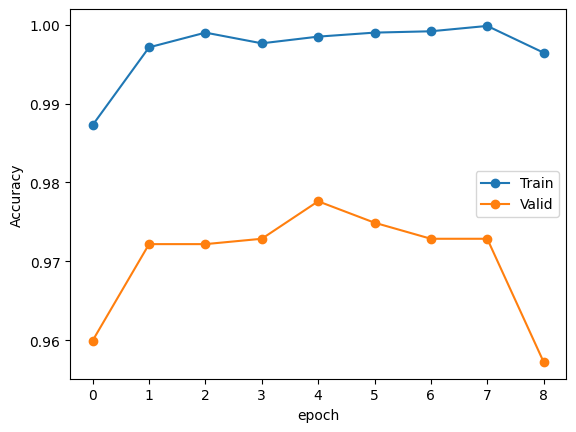

In [23]:
from torchsampler import ImbalancedDatasetSampler
# decision_dl = DataLoader(decisionset, batch_size=32)
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,model_0=model_0)

In [24]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)

Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

Epoch=0,train_loss=0.03719742857898749,train_accu=0.9930843706777317
Epoch=0,valid_loss=0.21119651275296364,valid_accu=0.9354838709677419
0
Epoch=1,train_loss=0.006023249928491708,train_accu=1.0
Epoch=1,valid_loss=0.15871058752940548,valid_accu=0.9419354838709677
0
Epoch=2,train_loss=0.003105788970369985,train_accu=1.0
Epoch=2,valid_loss=0.1437218535030561,valid_accu=0.9548387096774194
0
Epoch=3,train_loss=0.0012953737831157973,train_accu=1.0
Epoch=3,valid_loss=0.14117939347221006,valid_accu=0.9419354838709677
Epoch=4,train_loss=0.0013273862985324727,train_accu=1.0
Epoch=4,valid_loss=0.10517996001628137,valid_accu=0.967741935483871
0
Epoch=5,train_loss=0.0010105602407472448,train_accu=1.0
Epoch=5,valid_loss=0.10990041936597517,valid_accu=0.9612903225806452
Epoch=6,train_loss=0.000421070124545646,train_accu=1.0
Epoch=6,valid_loss=0.11725978942648058,valid_accu=0.9612903225806452
Epoch=7,train_loss=0.00026703917010082514,train_accu=1.0
Epoch=7,valid_loss=0.13138835910827884,valid_accu=0.

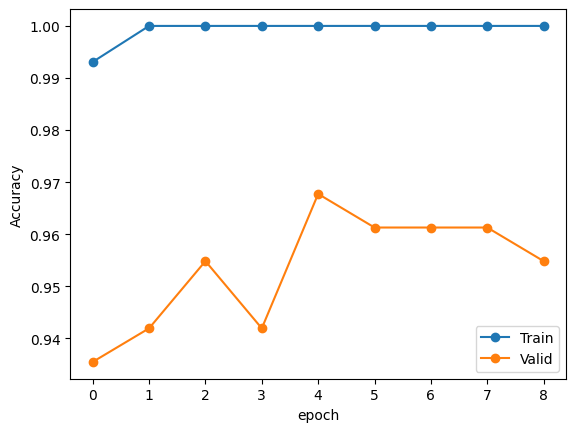

In [25]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70,model_0=model_0)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

Epoch=0,train_loss=0.07637495608384964,train_accu=0.9829885946259423
Epoch=0,valid_loss=0.3928378970899575,valid_accu=0.890068233510235
0
Epoch=1,train_loss=0.027365886254307036,train_accu=0.9947805915329596
Epoch=1,valid_loss=0.33731055695781026,valid_accu=0.9097801364670205
0
Epoch=2,train_loss=0.016989230703459517,train_accu=0.996133771505896
Epoch=2,valid_loss=0.35093016390370274,valid_accu=0.9037149355572404
Epoch=3,train_loss=0.011867075642159833,train_accu=0.9972936400541272
Epoch=3,valid_loss=0.3701852206437311,valid_accu=0.9006823351023503
Epoch=4,train_loss=0.018140880138412183,train_accu=0.9955538372317804
Epoch=4,valid_loss=0.40038684141554554,valid_accu=0.8999241849886277
Epoch=5,train_loss=0.0037772245857707627,train_accu=0.9992267543011792
Epoch=5,valid_loss=0.32876891562033095,valid_accu=0.9241849886277483
0
Epoch=6,train_loss=0.0054006913785599265,train_accu=0.9984535086023584
Epoch=6,valid_loss=0.35917815073005643,valid_accu=0.9097801364670205
Epoch=7,train_loss=0.002

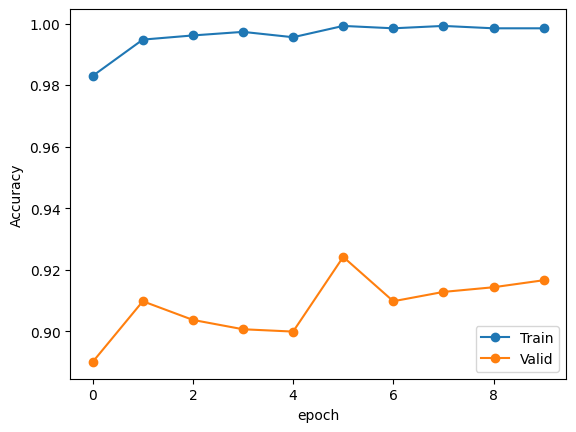

In [53]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70,model_0=model_0)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [27]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.0034558978283756774, 0.9988127544097694)

In [28]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.07193799431750417, 0.9776119402985075)

In [29]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.001356735930521747, 1.0)

In [30]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.002698260399718029, 0.9996133771505896)

In [31]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.09626769529234978, 0.967741935483871)

In [32]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.4022497596858893, 0.909021986353298)

In [33]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d

(0.003198270323100908, 0.9994911804613297)

In [34]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.35948318492980064, 0.9145183175033921, 1319)

In [35]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.07003245099880948, 0.9954206241519674, 5162, 734)

In [36]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.7474784587251451, 0.8921302578018996, 1313, 161)

In [37]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_valid_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [38]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_with_perfect_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
print(f'splitmode={split_mode}')
df

splitmode=('classaccu', [29, 31, 98, 89, 28, 12, 36, 51, 45, 18, 3, 47, 26, 5, 58, 73, 95, 13, 1, 83, 64, 34, 96, 17, 38, 97, 39, 99, 32, 37, 24, 49, 72, 33, 40, 78, 90, 0, 2, 4, 6, 7, 8, 9, 10, 11, 14, 15, 16, 19, 20, 21, 22, 23, 25, 27, 30, 35, 41, 42, 43, 44, 46, 48, 50, 52, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 65, 66, 67, 68, 69, 70, 71, 74, 75, 76, 77, 79, 80, 81])


,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.025638,0.993385,0.452852,0.887381
1,Model_Decision,0.003456,0.998813,0.071938,0.977612
2,Model_T,0.001357,1.000000,0.096268,0.967742
3,Model_F,0.002698,0.999613,0.402250,0.909022
4,Total_Model,0.070032,0.995421,0.747478,0.892130
5,Total_Model_with_perfect_decision,0.003198,0.999491,0.359483,0.914518


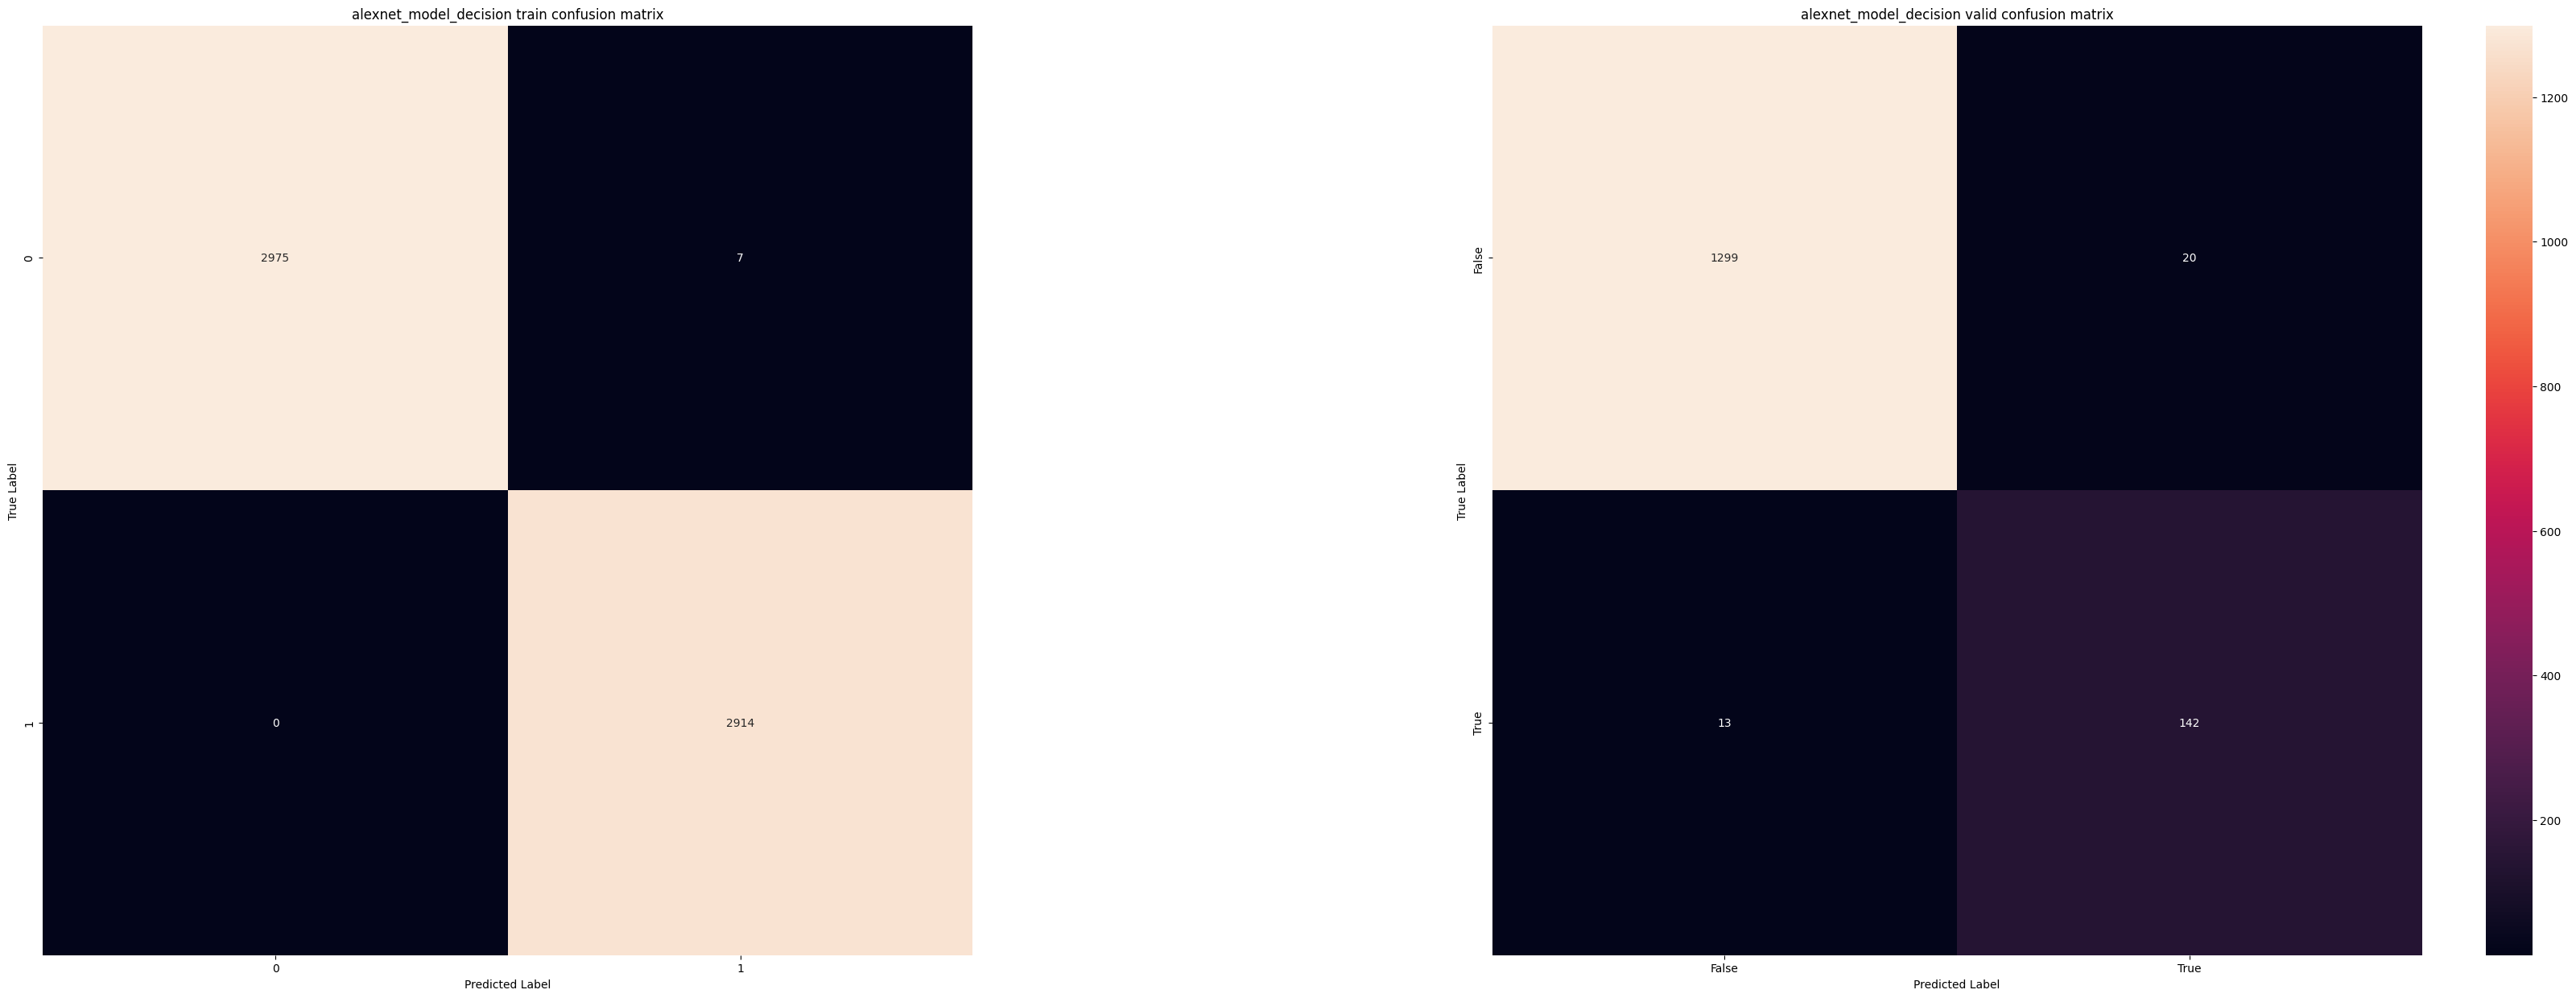

In [39]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

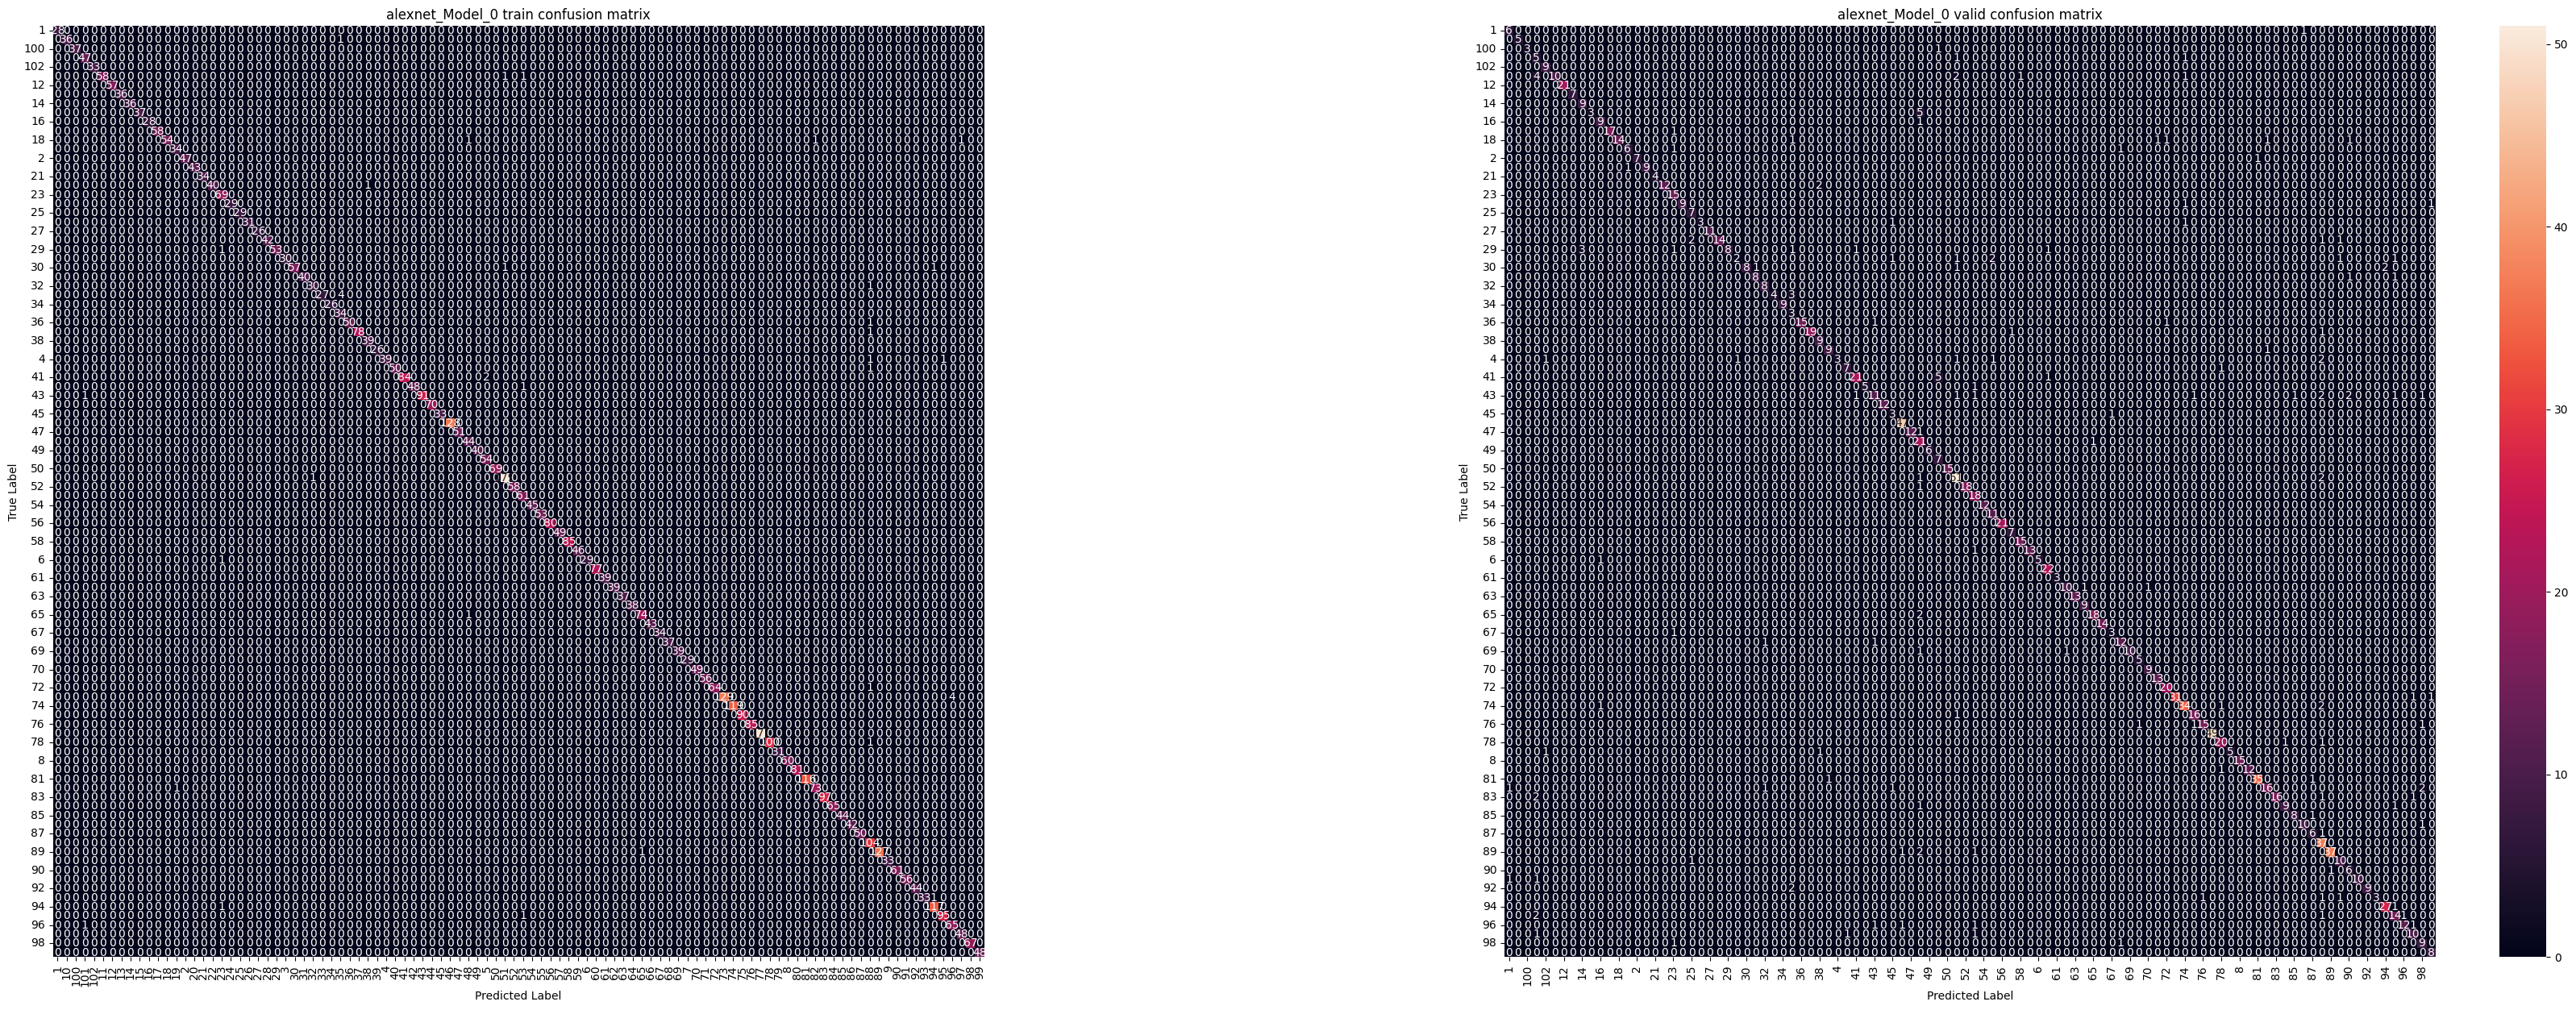

In [40]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

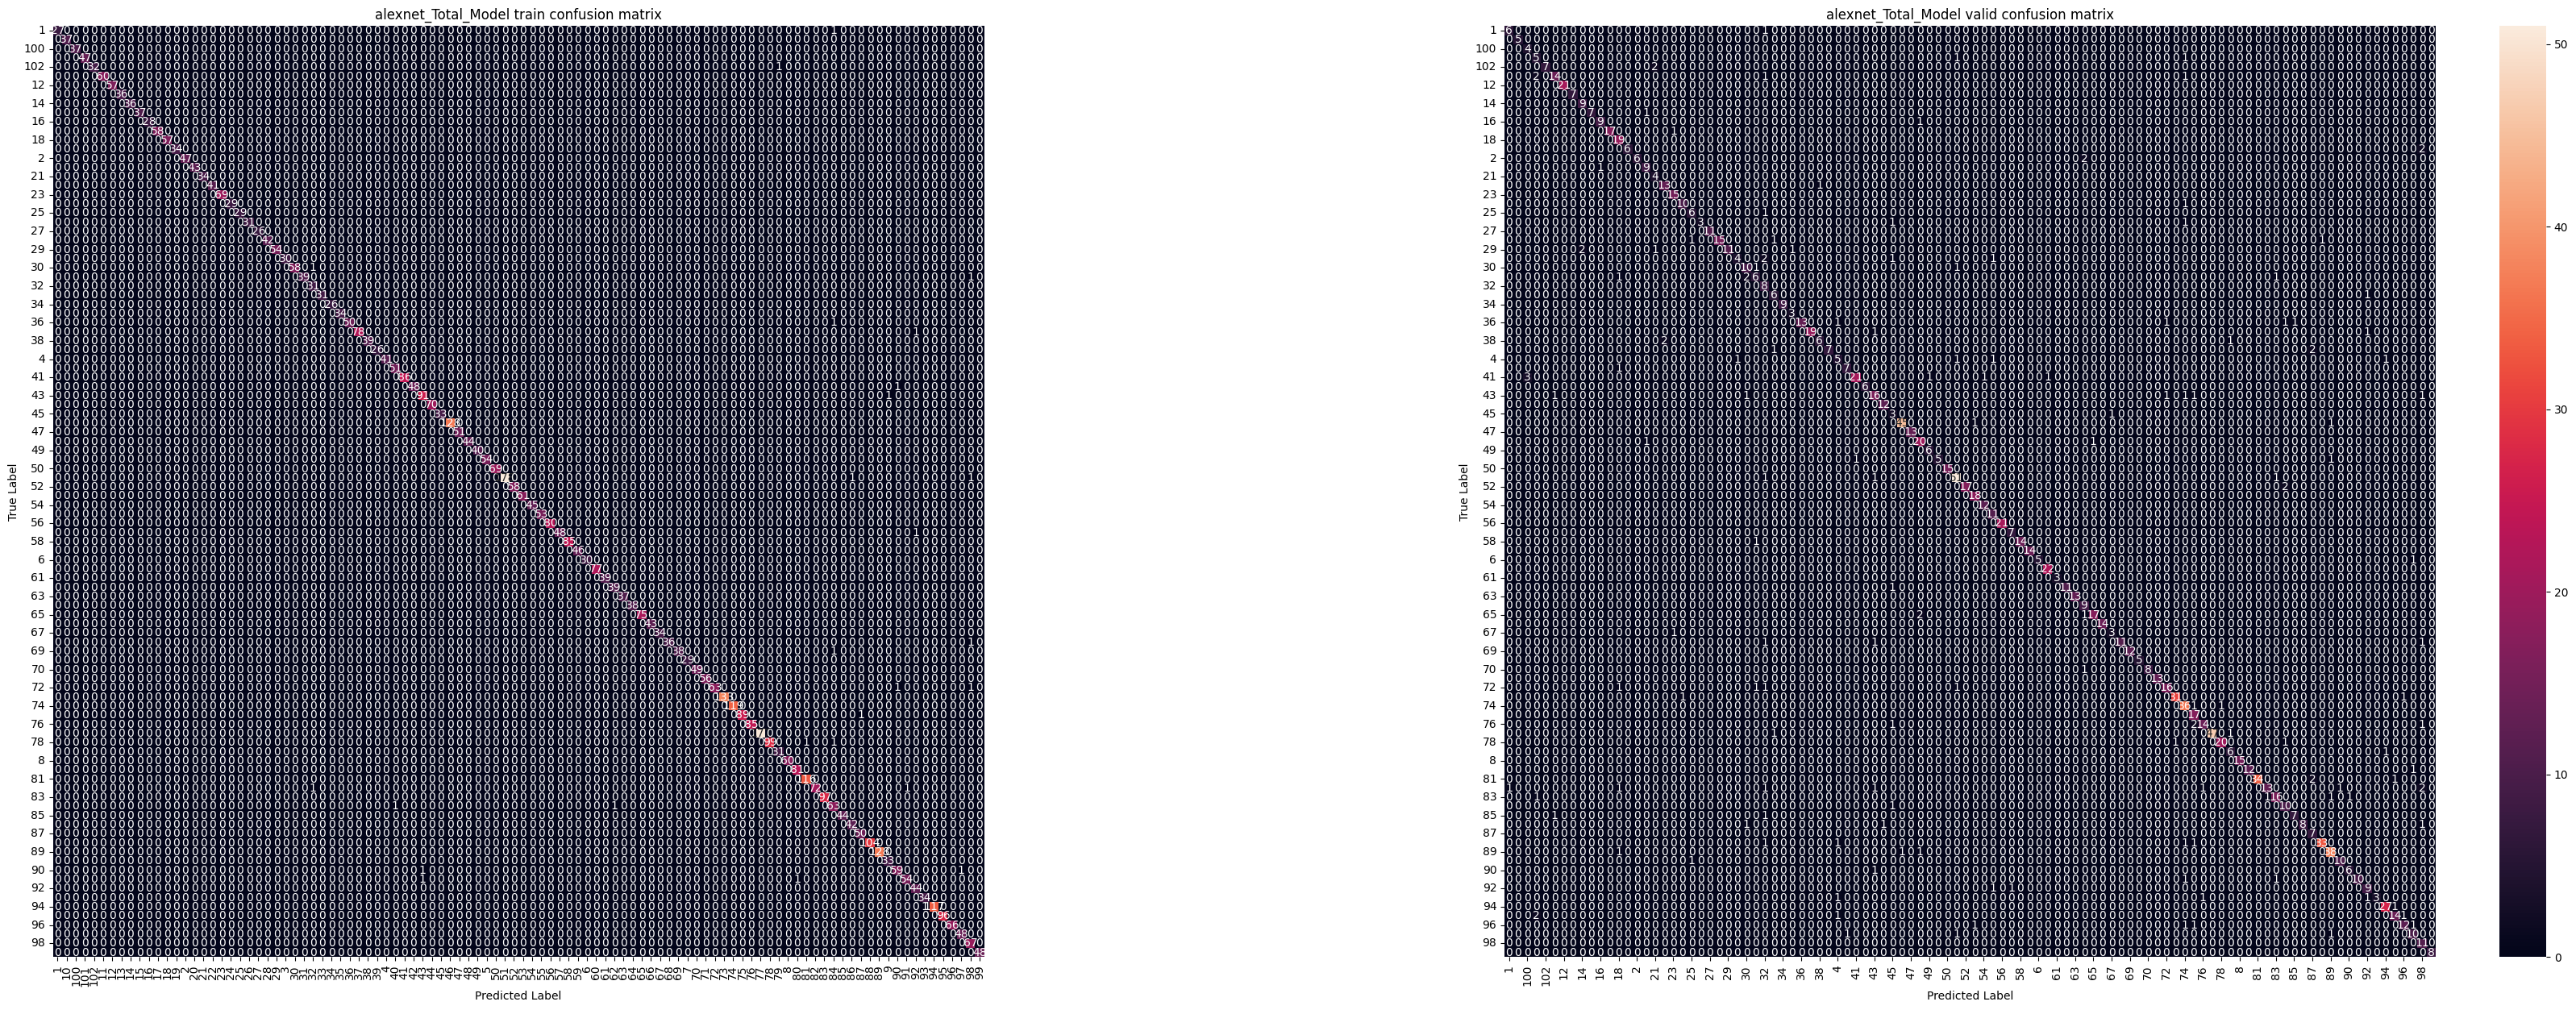

In [41]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

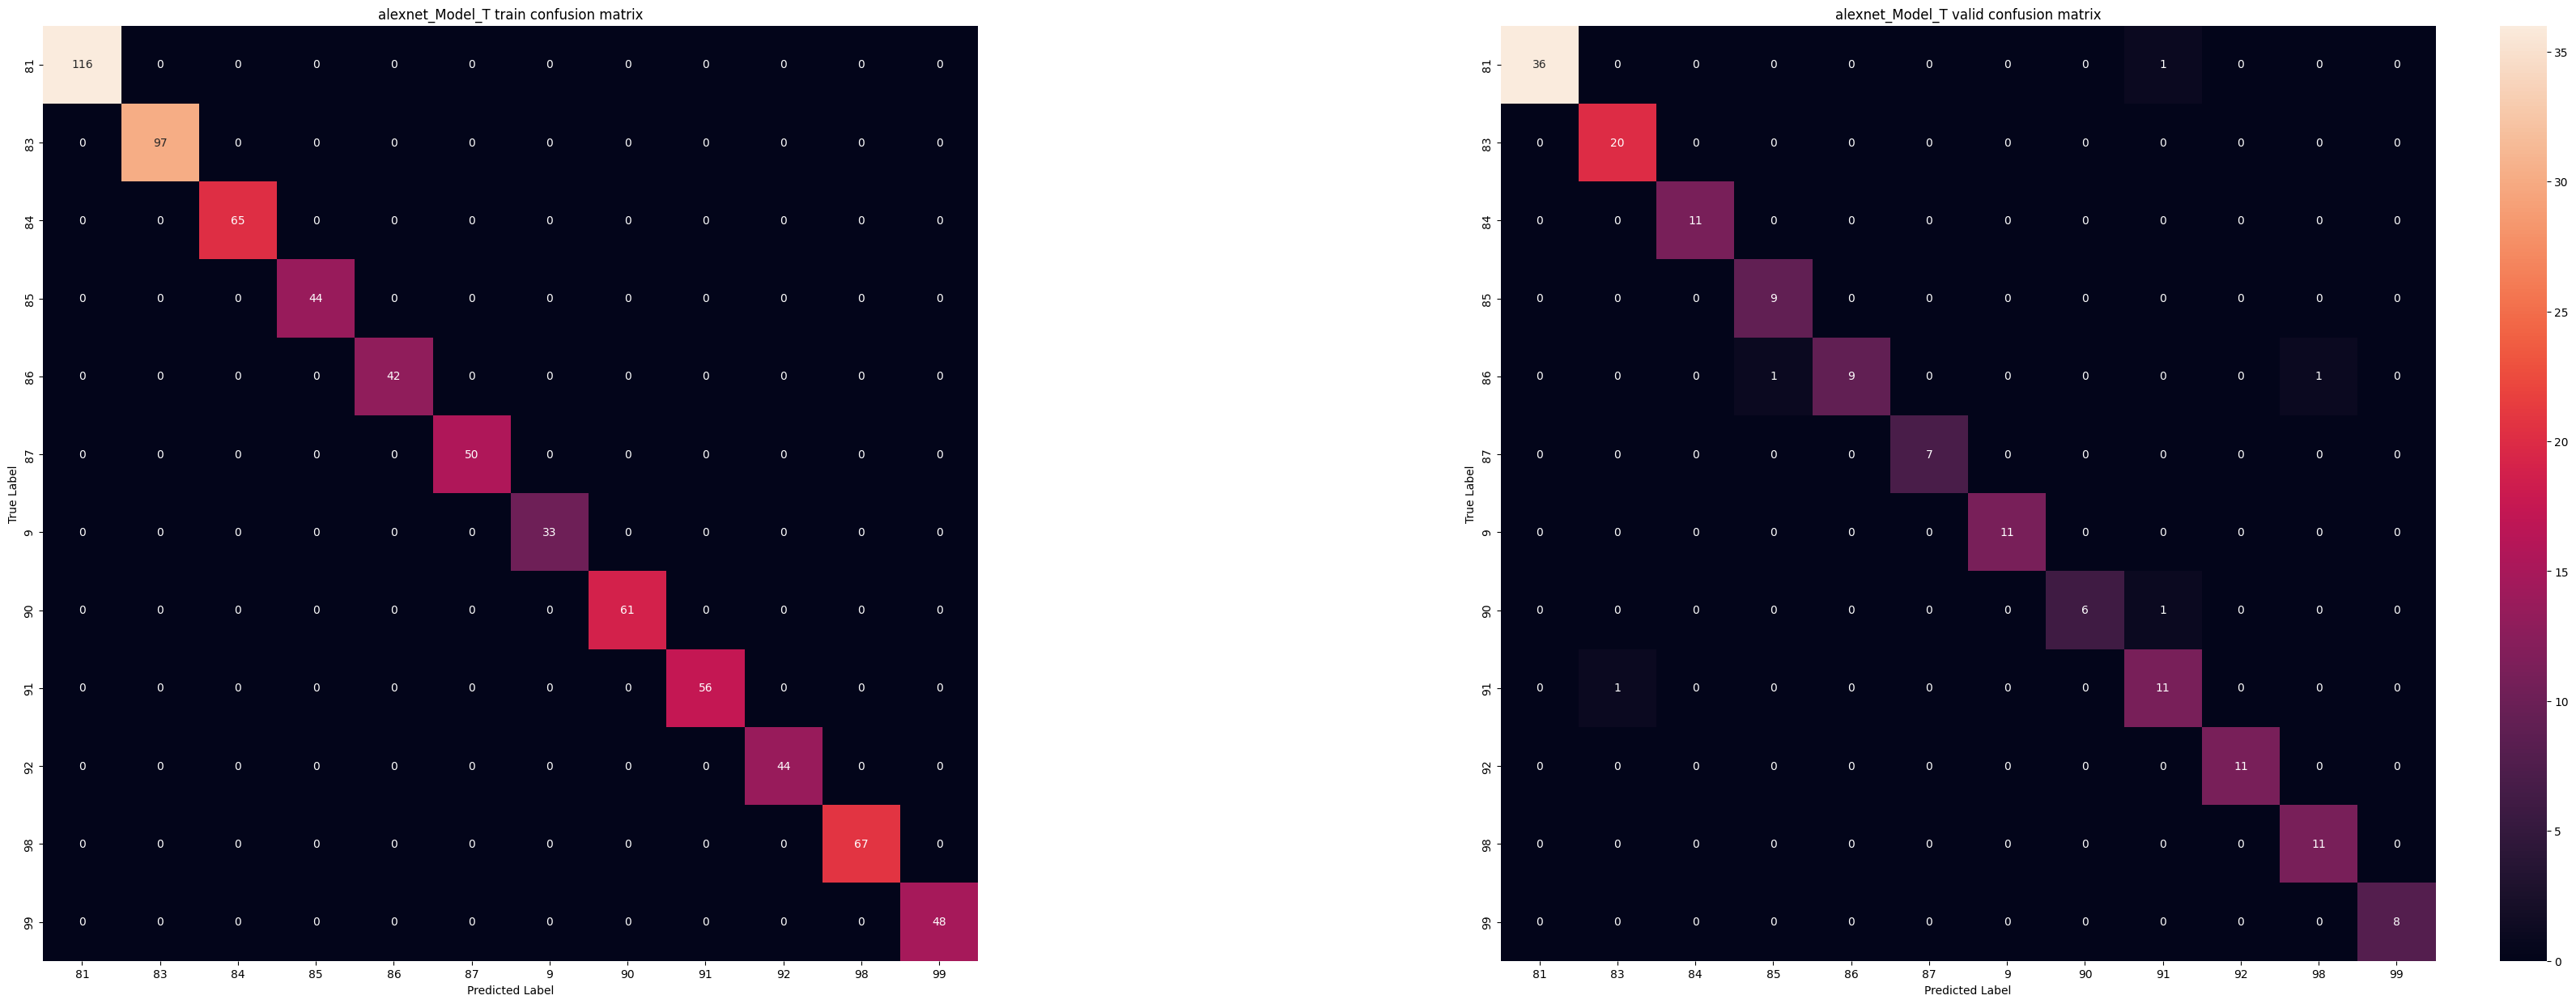

In [42]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

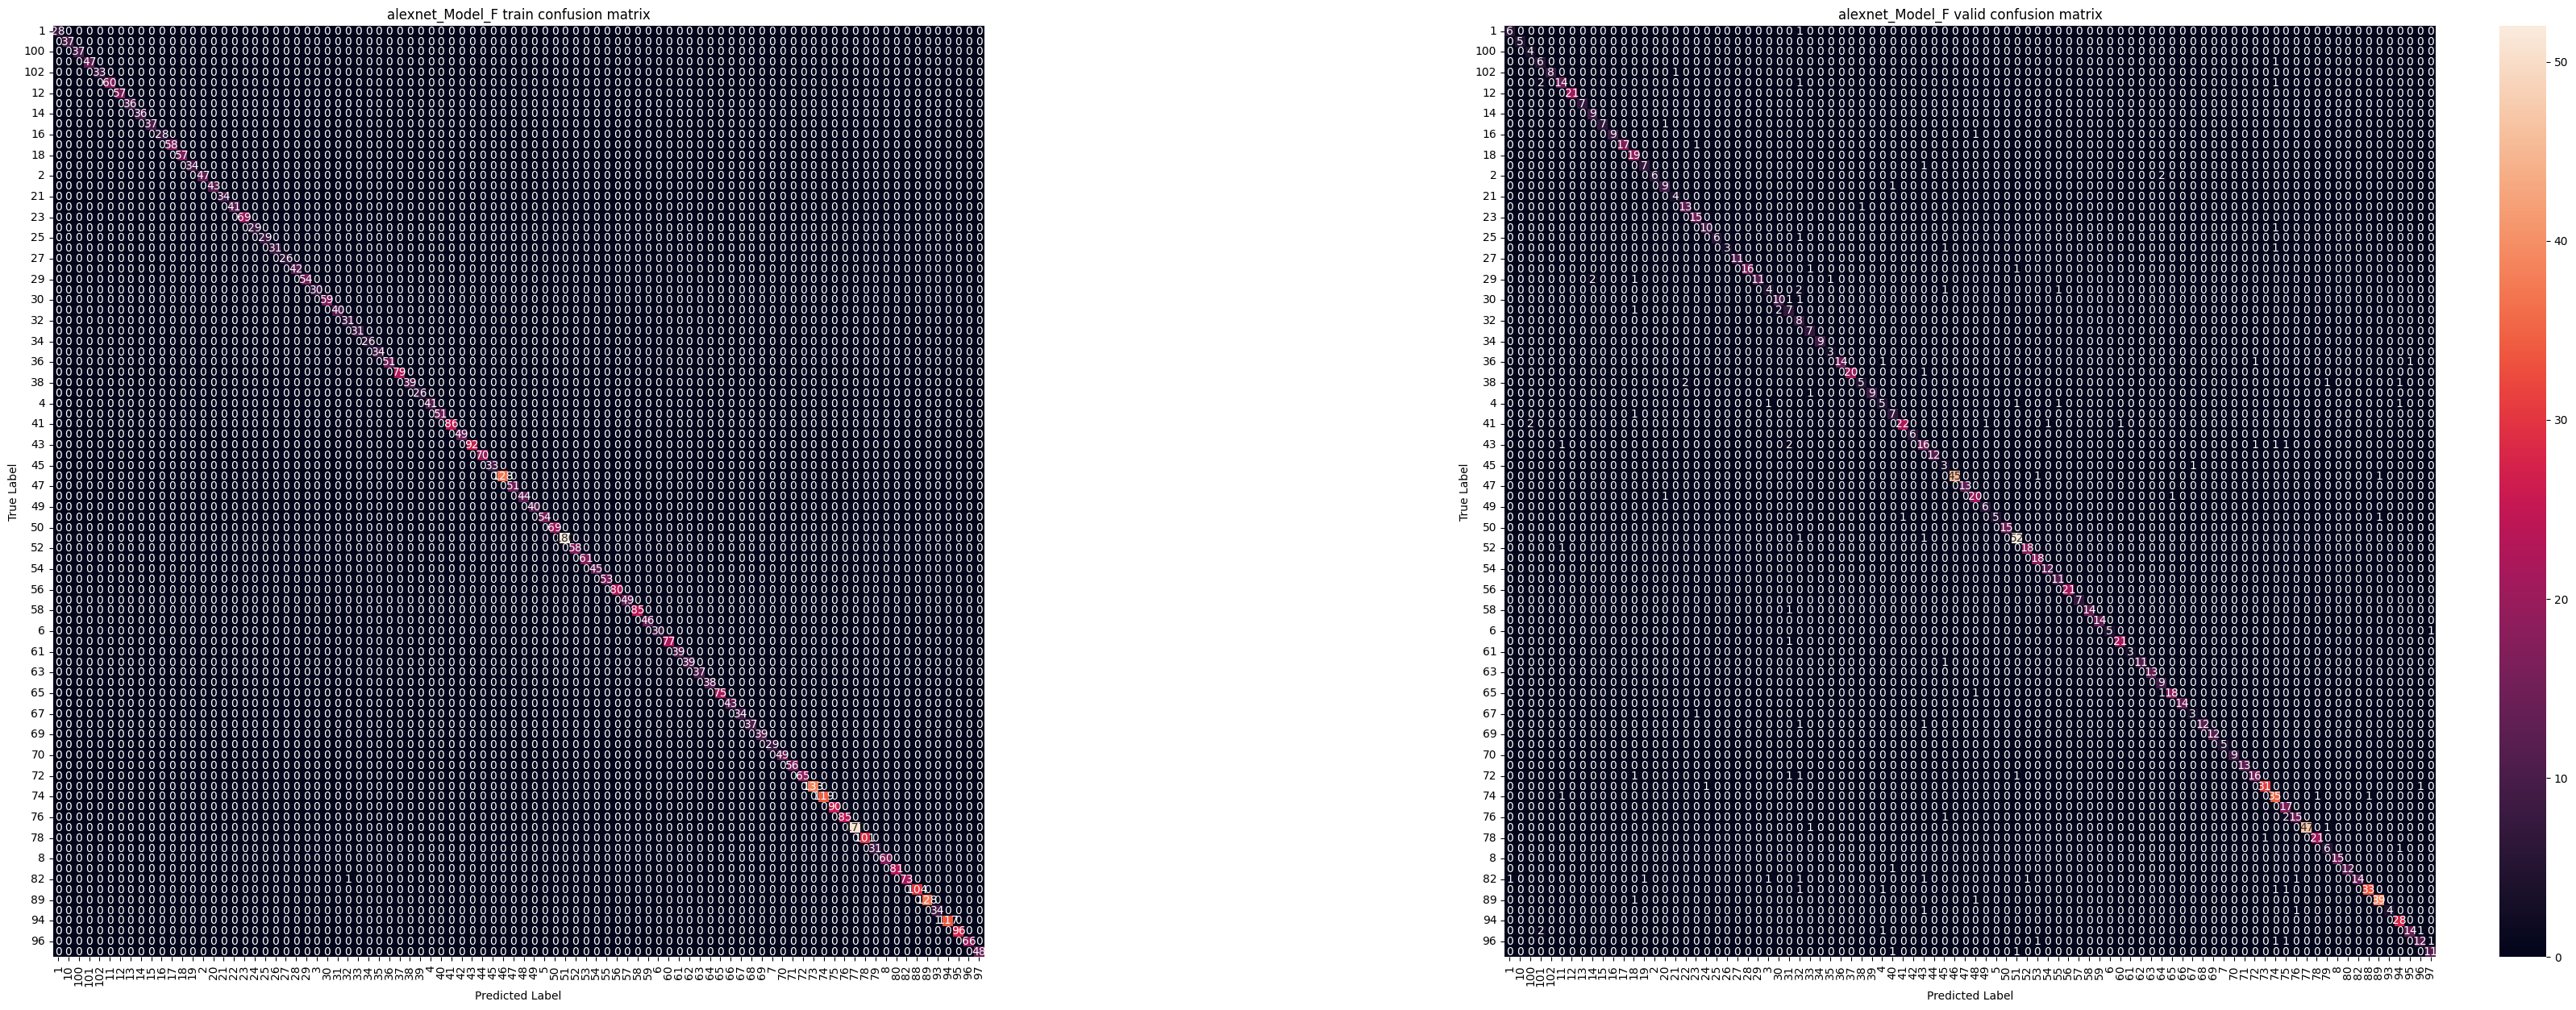

In [43]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [65]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)

            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
        
                if(softmax_decision>0.9):

                    if(pred_decision==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                    if(softmax_F>softmax_T):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [66]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.057319390693301296, 0.9966078697421981, 5162, 734)

In [67]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(0.5602551556446336, 0.9138398914518318, 1314, 160)

In [44]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [45]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,4258,68,68,85,68,0.999999,0.997411,0.995297,1.000000,True,False,True,False,False
1,3688,57,57,101,57,0.999943,0.991103,0.999986,0.999993,True,False,True,False,False
2,5733,82,51,82,82,0.997602,1.000000,1.000000,1.000000,False,True,True,True,True
3,1221,23,23,91,23,1.000000,0.996425,0.999998,1.000000,True,False,True,False,False
4,5426,78,78,88,78,0.998134,0.448922,0.977843,1.000000,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5891,5162,77,77,94,77,0.999962,0.980645,0.999992,1.000000,True,False,True,False,False
5892,6172,87,49,87,87,0.451288,1.000000,0.999967,0.999991,False,True,True,True,True
5893,456,8,8,94,8,0.999964,0.993618,0.998453,0.999997,True,False,True,False,False
5894,1214,23,23,91,23,0.999449,0.999997,0.980055,0.999995,True,False,True,False,False


In [56]:
len(df_results[(df_results['Decision']!=df_results['flag'])&(df_results['Softmax_decision']<0.9)])

20

In [60]:
df_results[(df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
53,2345,42,42,91,42,0.999774,0.874794,0.993891,0.590205,True,False,True,False,False
77,1661,32,32,85,32,0.999980,0.724324,0.999063,0.778628,True,False,True,False,False
118,5324,78,78,82,78,0.999944,0.521535,0.889447,0.656732,True,False,True,False,False
205,5838,83,83,94,83,0.999973,0.603366,0.999806,0.854260,True,False,True,False,False
261,6625,92,99,92,92,0.441729,1.000000,0.999953,0.694168,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5610,2889,49,49,84,49,0.999994,0.998968,0.999765,0.609511,True,False,True,False,False
5677,6353,89,89,88,89,0.999978,0.954273,0.999931,0.896363,True,False,True,False,False
5681,1631,32,32,100,32,0.995529,0.979334,0.999303,0.530298,True,False,True,False,False
5757,2996,49,49,100,49,0.999914,0.802939,0.997530,0.574640,True,False,True,True,False


In [46]:
df_results[df_results['Decision']!=df_results['flag']]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
261,6625,92,99,92,92,0.441729,1.000000,0.999953,0.694168,False,True,True,False,True
549,3058,49,49,87,49,0.999881,0.995656,0.891038,0.672961,True,False,True,True,False
1048,5337,78,78,85,78,0.999995,0.805552,0.997526,0.927596,True,False,True,True,False
1199,1778,34,34,94,34,0.999479,0.997405,0.996302,0.657477,True,False,True,True,False
1271,4341,69,69,85,69,0.999717,0.968790,0.999995,0.995365,True,False,True,True,False
1340,4215,67,67,100,67,0.999999,0.999889,0.999451,0.843651,True,False,True,True,False
1990,1704,33,33,94,33,0.996018,0.702830,0.998939,0.552737,True,False,True,True,False
2138,6568,91,25,91,91,0.489758,0.998213,0.998512,0.729949,False,True,True,False,True
2273,4471,72,72,100,72,0.996295,0.962324,0.993932,0.819324,True,False,True,True,False
3303,6063,85,37,85,85,0.663862,0.999783,0.955026,0.791730,False,True,True,False,True


In [47]:
df=(df_results[(df_results['Decision']!=df_results['flag']) ])
target_counts = df['Target'].value_counts()
target_counts 

49    4
92    2
78    2
85    2
93    2
34    1
33    1
69    1
91    1
72    1
95    1
67    1
27    1
51    1
32    1
55    1
53    1
39    1
40    1
0     1
Name: Target, dtype: int64

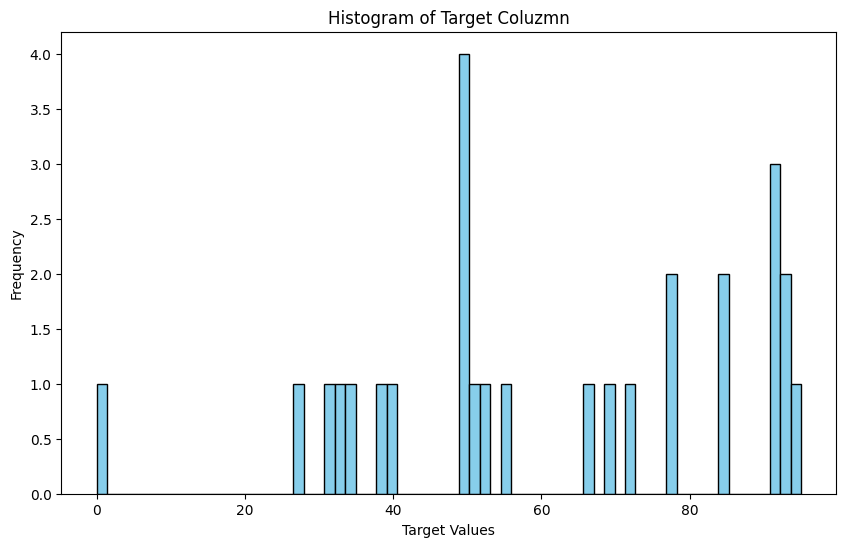

In [48]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Coluzmn')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()

In [49]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,4579,73,73,84,73,0.999999,0.837717,0.999461,1.000000,True,False,True,False,False
1,3586,56,56,84,56,1.000000,0.998739,0.999999,1.000000,True,False,True,False,False
2,3141,50,50,85,50,0.999972,0.999893,0.999812,0.999979,True,False,True,False,False
3,3499,55,55,94,55,0.999939,0.918930,0.999999,0.999430,True,False,True,False,False
4,6701,93,78,93,93,0.426928,0.996684,0.999888,0.999901,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,6995,97,97,92,97,0.998845,0.902508,0.984858,0.999999,True,False,True,False,False
1470,6319,89,89,88,89,0.999969,0.868246,0.999999,1.000000,True,False,True,False,False
1471,6577,91,20,91,20,0.999708,0.999994,0.827318,0.561197,False,True,False,True,True
1472,4089,64,64,85,64,0.972719,0.629051,0.815581,1.000000,True,False,True,False,False


In [50]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
26,2912,49,49,100,49,0.910882,0.910925,0.993944,0.720541,True,False,True,True,False
32,6621,92,40,93,40,0.778317,0.799070,0.401247,0.930995,False,False,False,False,True
63,6180,87,28,86,87,0.572825,0.511007,0.672986,0.999695,False,False,True,False,True
107,3169,50,5,85,50,0.986274,0.988405,0.535298,0.952392,False,False,True,True,False
149,4217,67,67,100,67,0.999585,0.999891,0.953478,0.929356,True,False,True,True,False
153,6746,94,55,94,31,0.430665,0.972823,0.412047,0.989522,False,True,False,False,True
206,6161,87,41,87,87,0.331154,0.999070,0.918854,0.669490,False,True,True,False,True
224,3113,50,50,85,50,0.999185,0.999837,0.999992,0.888653,True,False,True,True,False
227,1555,30,30,87,30,0.998714,0.999843,0.963032,0.582721,True,False,True,True,False
304,5680,82,97,93,35,0.496439,0.467211,0.725592,0.959034,False,False,False,False,True


In [51]:
df=df_results_v[(df_results_v['Decision']!=df_results_v['flag'])]
target_counts = df['Target'].value_counts()
target_counts 

50    3
87    2
13    2
83    2
94    2
32    2
35    2
86    2
49    1
67    1
92    1
40    1
82    1
91    1
30    1
93    1
95    1
76    1
84    1
85    1
33    1
Name: Target, dtype: int64

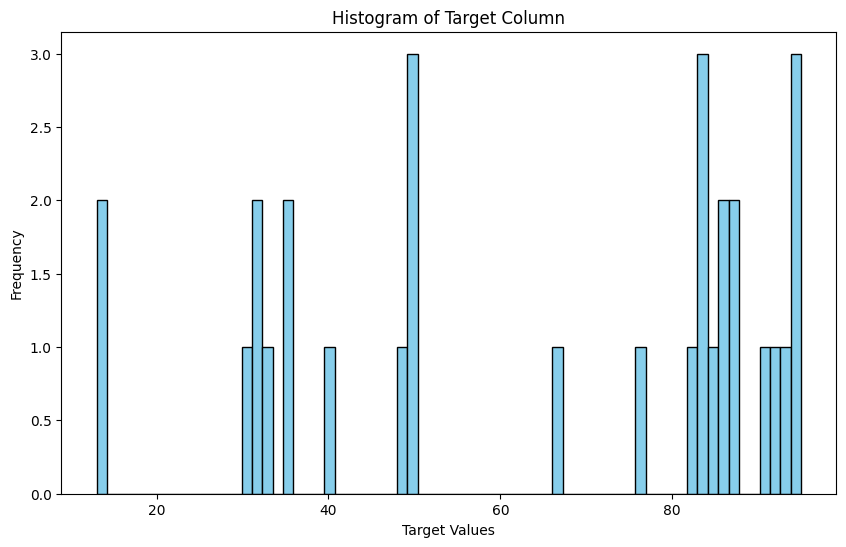

In [52]:
import matplotlib.pyplot as plt

# 设置图形大小
plt.figure(figsize=(10, 6))

# 绘制直方图
plt.hist(df['Target'], bins=68, color='skyblue', edgecolor='black')

# 添加标题和标签
plt.title('Histogram of Target Column')
plt.xlabel('Target Values')
plt.ylabel('Frequency')

# 显示图形
plt.show()